In [32]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mne.time_frequency import psd_array_welch
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from matplotlib import colors

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"MNE version: {mne.__version__}")

Libraries imported successfully!
MNE version: 1.10.1


## Data loading

In [33]:
patient = "XU"
freq = "7" 
dataset_sleep = f'{patient}SLEEP{freq}'
dataset_awake = f'{patient}AWAKE{freq}'

In [34]:
raw = mne.io.read_raw_edf(f'../data/XU/{dataset_awake}.EDF', preload=True, verbose=True)
raw_sleep = mne.io.read_raw_edf(f'../data/XU/{dataset_sleep}.EDF', preload=True, verbose=True)
raw_awake = mne.io.read_raw_edf(f'../data/XU/{dataset_awake}.EDF', preload=True, verbose=True)

Extracting EDF parameters from /Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/data/XU/XUAWAKE7.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 145407  =      0.000 ...   567.996 secs...
Extracting EDF parameters from /Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/data/XU/XUSLEEP7.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 163327  =      0.000 ...   637.996 secs...
Extracting EDF parameters from /Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/data/XU/XUAWAKE7.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 145407  =      0.000 ...   567.996 secs...


In [35]:
print("\n" + "="*60)
print("EEG DATA INFORMATION")
print("="*60)
print(f"Number of channels: {len(raw.ch_names)}")
print(f"Sampling frequency: {raw.info['sfreq']} Hz")
print(f"Duration: {raw.times[-1]:.2f} seconds ({raw.times[-1]/60:.2f} minutes)")
print(f"\nChannel names:\n{raw.ch_names}")


EEG DATA INFORMATION
Number of channels: 46
Sampling frequency: 256.0 Hz
Duration: 568.00 seconds (9.47 minutes)

Channel names:
['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'A1', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'A2', 'Fpz', 'Pz', 'T1', 'T2', 'EKGL', 'EKGR', 'LOC1', 'LOC2', 'EMG1', 'EMG2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR']


In [36]:
ch_types = {}
eeg_10_20 = ['Fp1','F7','T3','T5','O1','F3','C3','P3','Fz','Cz','Fp2',
             'F8','T4','T6','O2','F4','C4','P4','Fpz','Pz','T1','T2',
             'A1','A2']  # include A1, A2

for ch in raw.ch_names:
    if ch in eeg_10_20:
        ch_types[ch] = 'eeg'
    elif ch.startswith('EMG'):
        ch_types[ch] = 'emg'
    elif ch.startswith('EKG'):
        ch_types[ch] = 'ecg'
    else:
        ch_types[ch] = 'misc'

raw.set_channel_types(ch_types)

for ch in raw_awake.ch_names:
    if ch in eeg_10_20:
        ch_types[ch] = 'eeg'
    elif ch.startswith('EMG'):
        ch_types[ch] = 'emg'
    elif ch.startswith('EKG'):
        ch_types[ch] = 'ecg'
    else:
        ch_types[ch] = 'misc'
        
raw_awake.set_channel_types(ch_types)

for ch in raw_sleep.ch_names:
    if ch in eeg_10_20:
        ch_types[ch] = 'eeg'
    elif ch.startswith('EMG'):
        ch_types[ch] = 'emg'
    elif ch.startswith('EKG'):
        ch_types[ch] = 'ecg'
    else:
        ch_types[ch] = 'misc'
        
raw_sleep.set_channel_types(ch_types)

<RawEDF | XUSLEEP7.EDF, 46 x 163328 (638.0 s), ~57.4 MiB, data loaded>

In [37]:
# rereference to A2, the right mastoid and A1 the left mastoid
raw.set_eeg_reference(['A2', 'A1'])
raw_sleep.set_eeg_reference(['A2', 'A1'])
raw_awake.set_eeg_reference(['A2', 'A1'])

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


<RawEDF | XUAWAKE7.EDF, 46 x 145408 (568.0 s), ~51.1 MiB, data loaded>

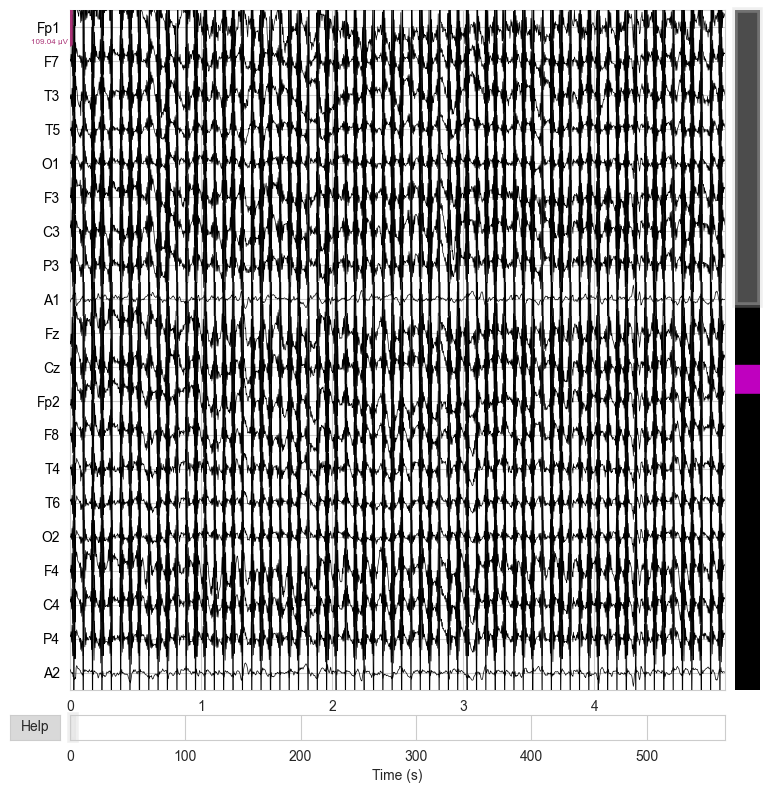

Displaying first 5 seconds of data
You can scroll through the data in the interactive plot


In [38]:
duration = 5  # seconds to display
n_channels = min(20, len(raw.ch_names))  # show max 20 channels

fig = raw.plot(duration=duration, n_channels=n_channels, 
               scalings='auto', title='Raw EEG Data',
               show=True, block=False)

print(f"Displaying first {duration} seconds of data")
print("You can scroll through the data in the interactive plot")

In [39]:
# get total duration in seconds
total_duration = raw.times[-1]
start = int((total_duration / 2) * raw.info['sfreq'])  # midpoint in samples
stop = start + int(duration * raw.info['sfreq'])  # 5 seconds later in samples

# print total duration in minutes
print(f"\nTotal recording duration: {total_duration/60:.2f} minutes")


Total recording duration: 9.47 minutes


In [40]:
try:
    # Try to set standard 10-20 montage
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='warn')
    raw_sleep.set_montage(montage, on_missing='warn')
    raw_awake.set_montage(montage, on_missing='warn')
    print("Montage set successfully!")
except:
    print("Could not set montage. Topographic plots may not be available.")

Montage set successfully!


## Preprocessing and visualization

In [41]:
raw_filtered = raw.copy()
raw_sleep_filtered = raw_sleep.copy()
raw_awake_filtered = raw_awake.copy()

In [42]:
# Apply bandpass filter (0.5 - 40 Hz is common for EEG)
raw_filtered.filter(l_freq=0.5, h_freq=40, fir_design='firwin')
raw_sleep_filtered.filter(l_freq=0.5, h_freq=40, fir_design='firwin')
raw_awake_filtered.filter(l_freq=0.5, h_freq=40, fir_design='firwin')

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband ed

<RawEDF | XUAWAKE7.EDF, 46 x 145408 (568.0 s), ~51.1 MiB, data loaded>

In [43]:
# Apply notch filter to remove line noise (50 Hz or 60 Hz depending on your region)
raw_filtered.notch_filter(freqs=[60], fir_design='firwin')
raw_sleep_filtered.notch_filter(freqs=[60], fir_design='firwin')
raw_awake_filtered.notch_filter(freqs=[60], fir_design='firwin')

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband e

<RawEDF | XUAWAKE7.EDF, 46 x 145408 (568.0 s), ~51.1 MiB, data loaded>

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

In [45]:
channel_idx = 0
channel_name = raw.ch_names[channel_idx]
times = raw.times[:int(10 * raw.info['sfreq'])]  # First 10 seconds

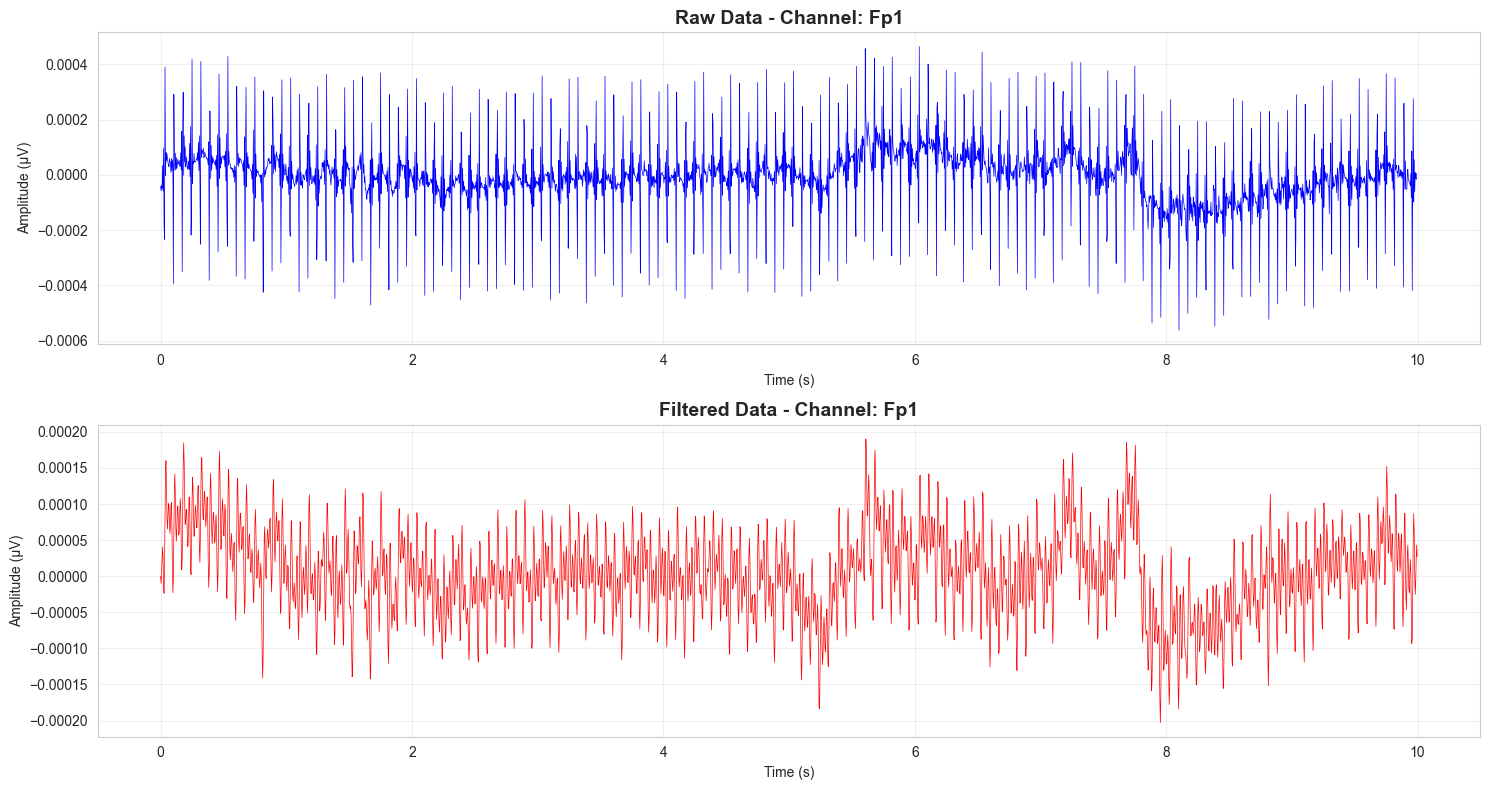

In [46]:
# Plot raw data
axes[0].plot(times, raw.get_data()[channel_idx, :len(times)], 'b-', linewidth=0.5)
axes[0].set_title(f'Raw Data - Channel: {channel_name}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].grid(True, alpha=0.3)

# Plot filtered data
axes[1].plot(times, raw_filtered.get_data()[channel_idx, :len(times)], 'r-', linewidth=0.5)
axes[1].set_title(f'Filtered Data - Channel: {channel_name}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

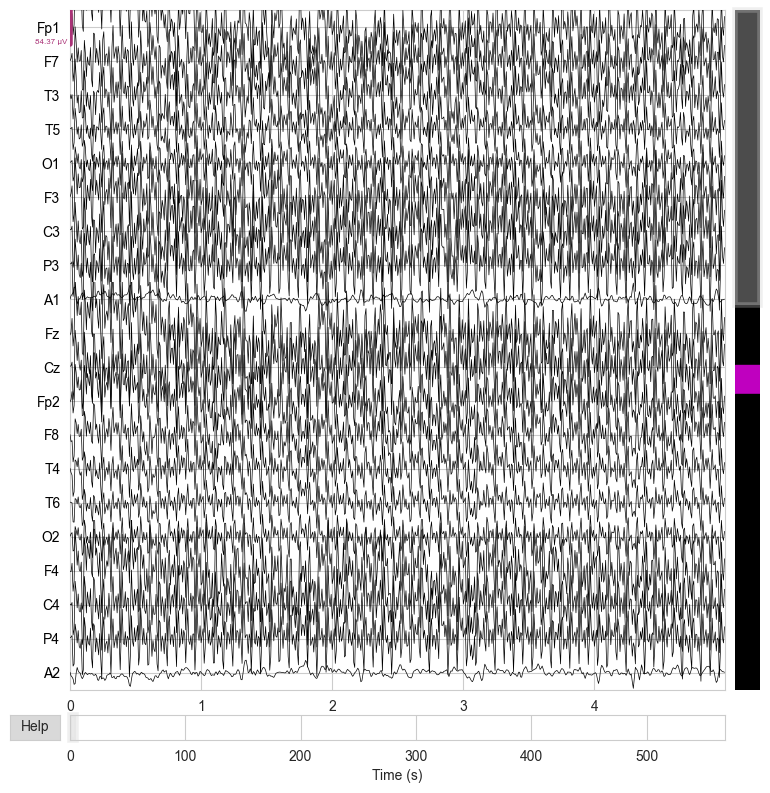

Displaying first 5 seconds of data
You can scroll through the data in the interactive plot


In [47]:
duration = 5  # seconds to display
n_channels = min(20, len(raw.ch_names))  # show max 20 channels

fig = raw_filtered.plot(duration=duration, n_channels=n_channels, 
               scalings='auto', title='Raw EEG Data',
               show=True, block=False)

print(f"Displaying first {duration} seconds of data")
print("You can scroll through the data in the interactive plot")

### Power Spectral Density (PSD) calculation and plotting

In [48]:
# Calculate PSD for all channels in raw data
psd_raw, freqs_raw = mne.time_frequency.psd_array_welch(
    raw.get_data(), 
    sfreq=raw.info['sfreq'], 
    fmin=0.5, fmax=125, n_fft=4096
)

psd_sleep, freqs_sleep = mne.time_frequency.psd_array_welch(
    raw_sleep.get_data(), 
    sfreq=raw_sleep.info['sfreq'], 
    fmin=0.5, fmax=125, n_fft=4096
)

psd_awake, freqs_awake = mne.time_frequency.psd_array_welch(
    raw_awake.get_data(), 
    sfreq=raw_awake.info['sfreq'], 
    fmin=0.5, fmax=125, n_fft=4096
)

Effective window size : 16.000 (s)
Effective window size : 16.000 (s)
Effective window size : 16.000 (s)


In [49]:
# Filtered data PSD
psd_filt, freqs_filt = mne.time_frequency.psd_array_welch(
    raw_filtered.get_data(),
    sfreq=raw_filtered.info['sfreq'], 
    fmin=0.5, fmax=200, n_fft=4096
)

psd_sleep_filt, freqs_sleep_filt = mne.time_frequency.psd_array_welch(
    raw_sleep_filtered.get_data(),
    sfreq=raw_sleep_filtered.info['sfreq'], 
    fmin=0.5, fmax=200, n_fft=4096
)

psd_awake_filt, freqs_awake_filt = mne.time_frequency.psd_array_welch(
    raw_awake_filtered.get_data(),
    sfreq=raw_awake_filtered.info['sfreq'], 
    fmin=0.5, fmax=200, n_fft=4096
)

Effective window size : 16.000 (s)
Effective window size : 16.000 (s)
Effective window size : 16.000 (s)


In [50]:
# save PSD data for later use
np.savez('psd_data.npz', freqs_raw=freqs_raw, psd_raw=psd_raw, freqs_filt=freqs_filt, psd_filt=psd_filt, info=raw.info, patient_id='XU', state='AWAKE', channel_name=channel_name)
np.savez('psd_sleep_data.npz', freqs_sleep=freqs_sleep, psd_sleep=psd_sleep, freqs_sleep_filt=freqs_sleep_filt, psd_sleep_filt=psd_sleep_filt, info=raw_sleep.info, patient_id='XU', state='SLEEP', channel_name=channel_name)
np.savez('psd_awake_data.npz', freqs_awake=freqs_awake, psd_awake=psd_awake, freqs_awake_filt=freqs_awake_filt, psd_awake_filt=psd_awake_filt, info=raw_awake.info, patient_id='XU', state='AWAKE', channel_name=channel_name)

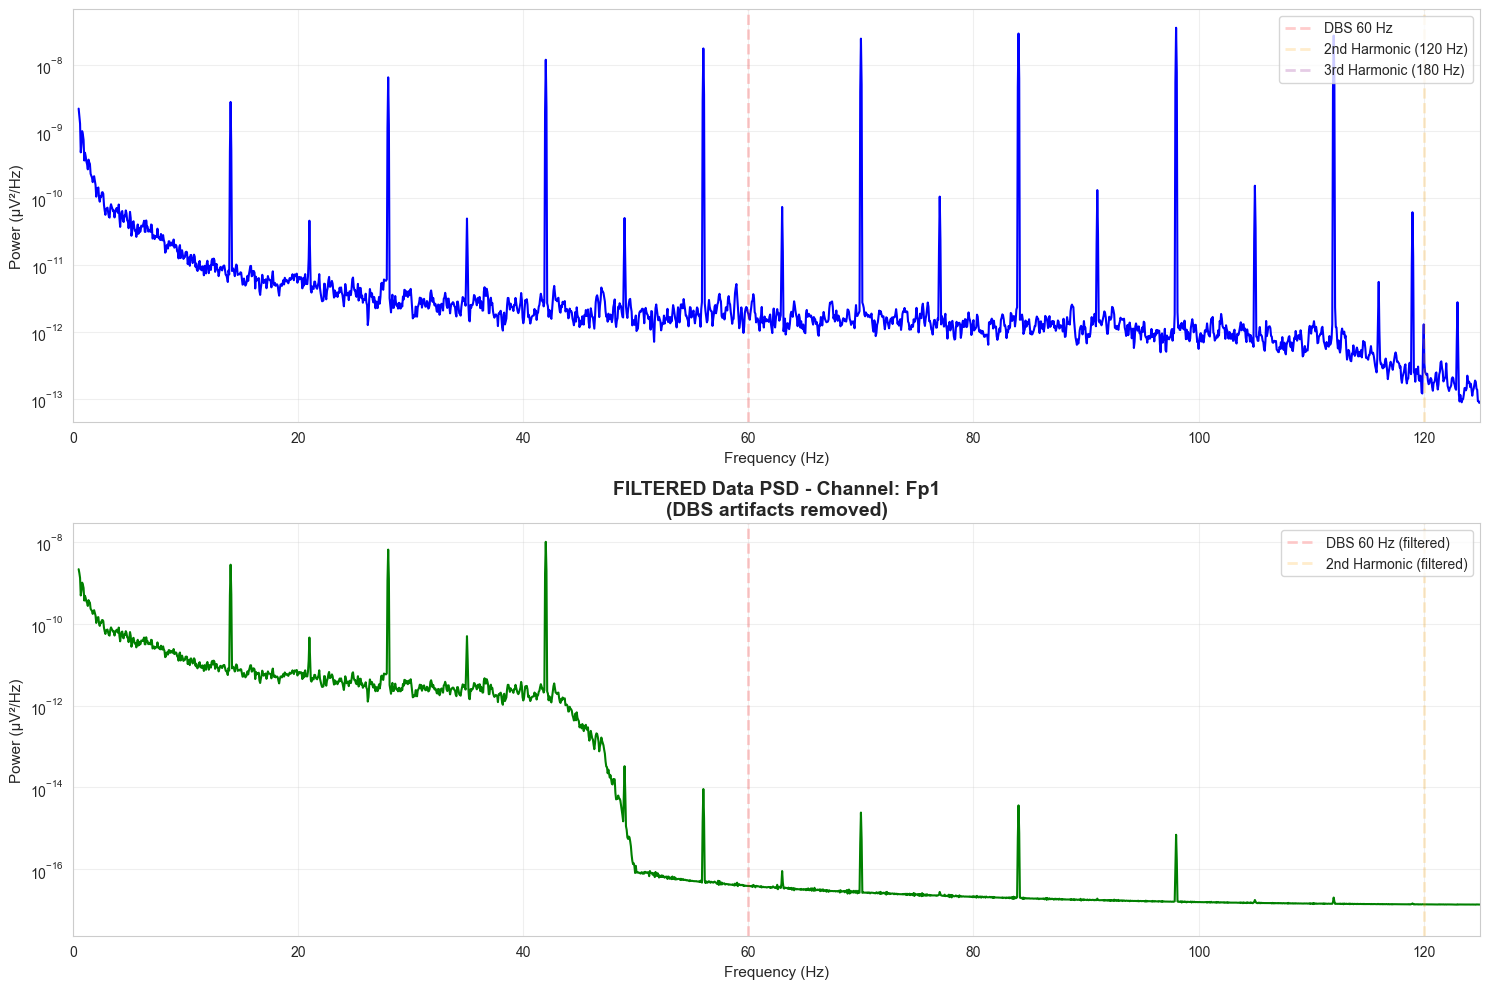

In [51]:
#Plot raw PSD
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes[0].semilogy(freqs_raw, psd_raw[0], 'b-', linewidth=1.5)
axes[0].axvline(60, color='red', linestyle='--', linewidth=2, label='DBS 60 Hz', alpha=0.2)
axes[0].axvline(120, color='orange', linestyle='--', linewidth=2, label='2nd Harmonic (120 Hz)', alpha=0.2)
axes[0].axvline(180, color='purple', linestyle='--', linewidth=2, label='3rd Harmonic (180 Hz)', alpha=0.2)
# axes[0].set_title(f'RAW Data PSD - Channel: {channel_name}\n(DBS artifacts visible at 60 Hz and harmonics)', 
                #  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency (Hz)', fontsize=11)
axes[0].set_ylabel('Power (µV²/Hz)', fontsize=11)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 125])

# Plot filtered PSD
axes[1].semilogy(freqs_filt, psd_filt[0], 'g-', linewidth=1.5)
axes[1].axvline(60, color='red', linestyle='--', linewidth=2, alpha=0.2, label='DBS 60 Hz (filtered)')
axes[1].axvline(120, color='orange', linestyle='--', linewidth=2, alpha=0.2, label='2nd Harmonic (filtered)')
# axes[1].axvline(180, color='purple', linestyle='--', linewidth=2, alpha=0.2, label='3rd Harmonic (filtered)')
axes[1].set_title(f'FILTERED Data PSD - Channel: {channel_name}\n(DBS artifacts removed)', 
                 fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency (Hz)', fontsize=11)
axes[1].set_ylabel('Power (µV²/Hz)', fontsize=11)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 125])

plt.tight_layout()
plt.show()

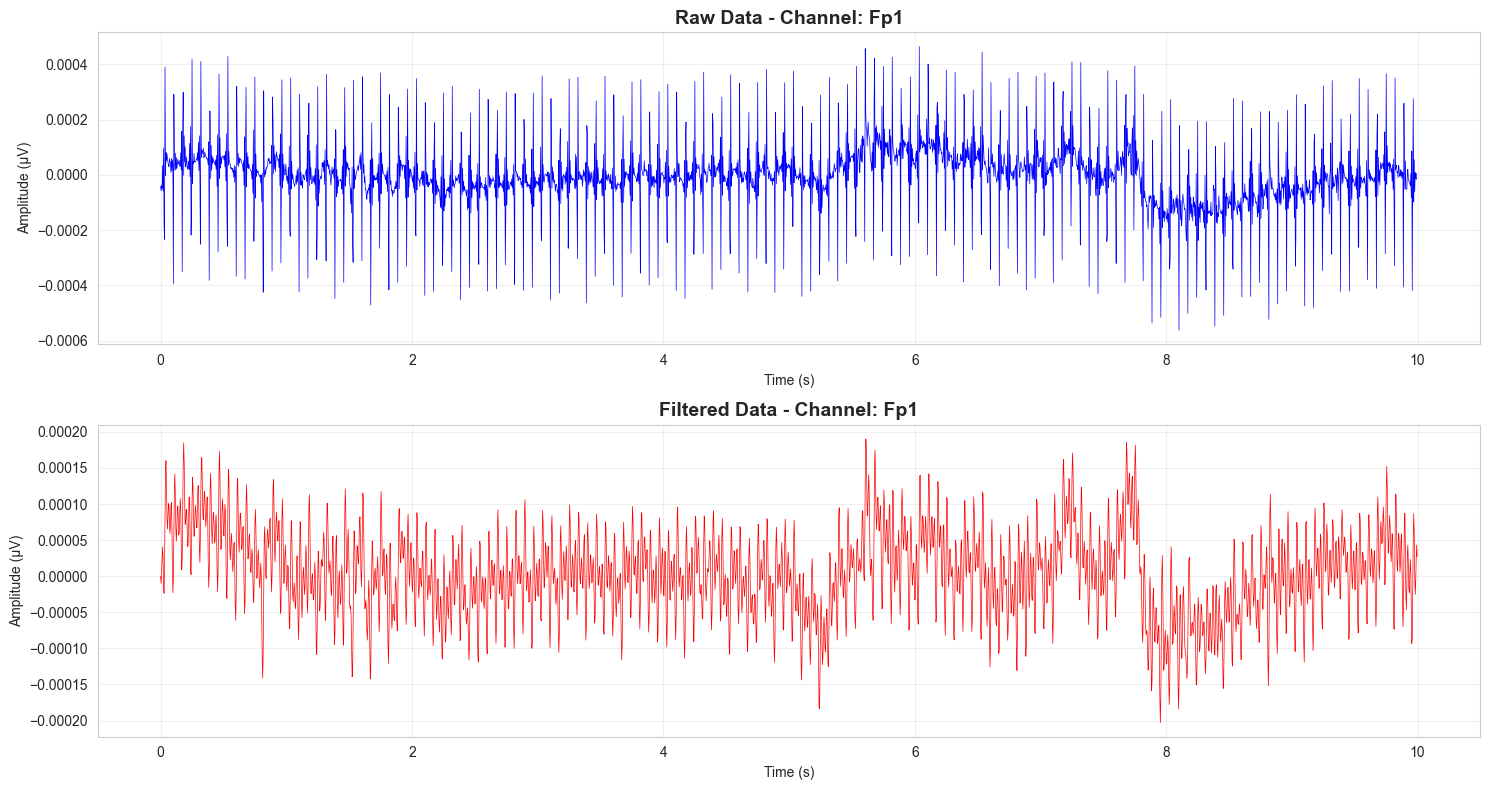

In [52]:
times = raw.times[:int(10 * raw.info['sfreq'])]  # First 10 seconds
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
# Plot raw data
axes[0].plot(times, raw.get_data()[channel_idx, :len(times)], 'b-', linewidth=0.5)
axes[0].set_title(f'Raw Data - Channel: {channel_name}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].grid(True, alpha=0.3)

# Plot filtered data
axes[1].plot(times, raw_filtered.get_data()[channel_idx, :len(times)], 'r-', linewidth=0.5)
axes[1].set_title(f'Filtered Data - Channel: {channel_name}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

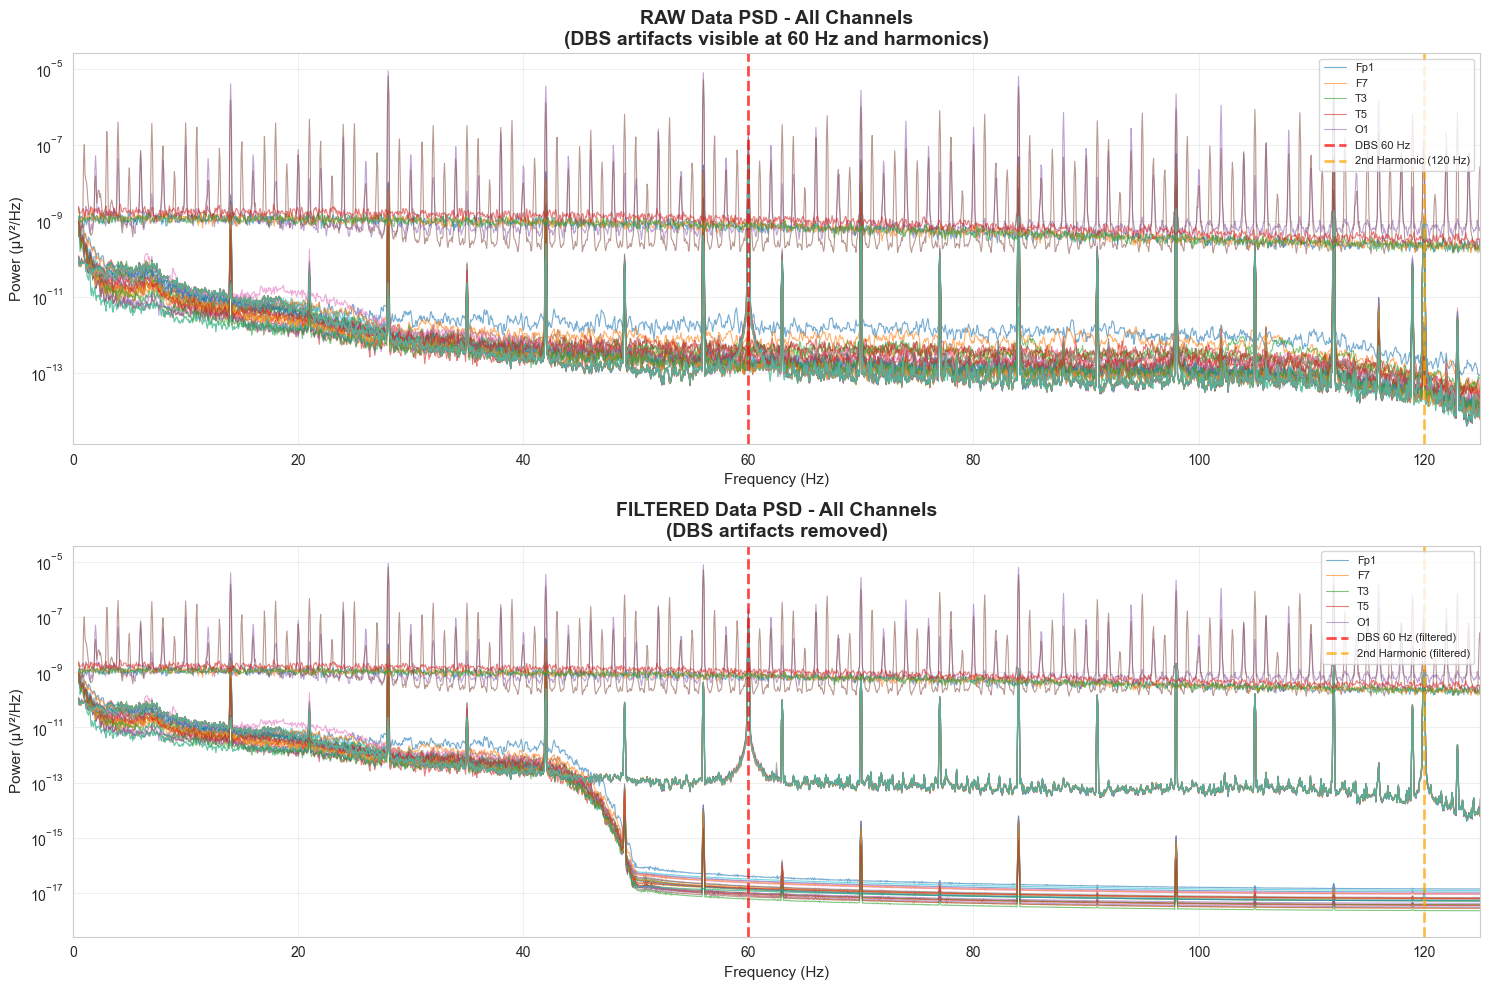

In [53]:
# Plot PSD for all channels (individual lines)
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot raw PSD (all channels)
for i, ch_name in enumerate(raw.ch_names):
    axes[0].semilogy(freqs_raw, psd_raw[i], linewidth=0.8, alpha=0.6, label=ch_name if i < 5 else "")

axes[0].axvline(60, color='red', linestyle='--', linewidth=2, label='DBS 60 Hz', alpha=0.7)
axes[0].axvline(120, color='orange', linestyle='--', linewidth=2, label='2nd Harmonic (120 Hz)', alpha=0.7)
# axes[0].axvline(180, color='purple', linestyle='--', linewidth=2, label='3rd Harmonic (180 Hz)', alpha=0.7)
axes[0].set_title(f'RAW Data PSD - All Channels\n(DBS artifacts visible at 60 Hz and harmonics)', 
                 fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency (Hz)', fontsize=11)
axes[0].set_ylabel('Power (µV²/Hz)', fontsize=11)
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 125])

# Plot filtered PSD (all channels)
for i, ch_name in enumerate(raw.ch_names):
    axes[1].semilogy(freqs_filt, psd_filt[i], linewidth=0.8, alpha=0.6, label=ch_name if i < 5 else "")

axes[1].axvline(60, color='red', linestyle='--', linewidth=2, alpha=0.7, label='DBS 60 Hz (filtered)')
axes[1].axvline(120, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='2nd Harmonic (filtered)')
# axes[1].axvline(180, color='purple', linestyle='--', linewidth=2, alpha=0.7, label='3rd Harmonic (filtered)')
axes[1].set_title(f'FILTERED Data PSD - All Channels\n(DBS artifacts removed)', 
                 fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency (Hz)', fontsize=11)
axes[1].set_ylabel('Power (µV²/Hz)', fontsize=11)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 125])

plt.tight_layout()
plt.show()

In [54]:
# Define EEG frequency bands
bands = {
    'Delta (0.5-4 Hz)': (0.5, 4),
    'Theta (4-8 Hz)': (4, 8),
    'Alpha (8-13 Hz)': (8, 13),
    'Beta (13-30 Hz)': (13, 30),
    'Gamma (30-40 Hz)': (30, 40)
}

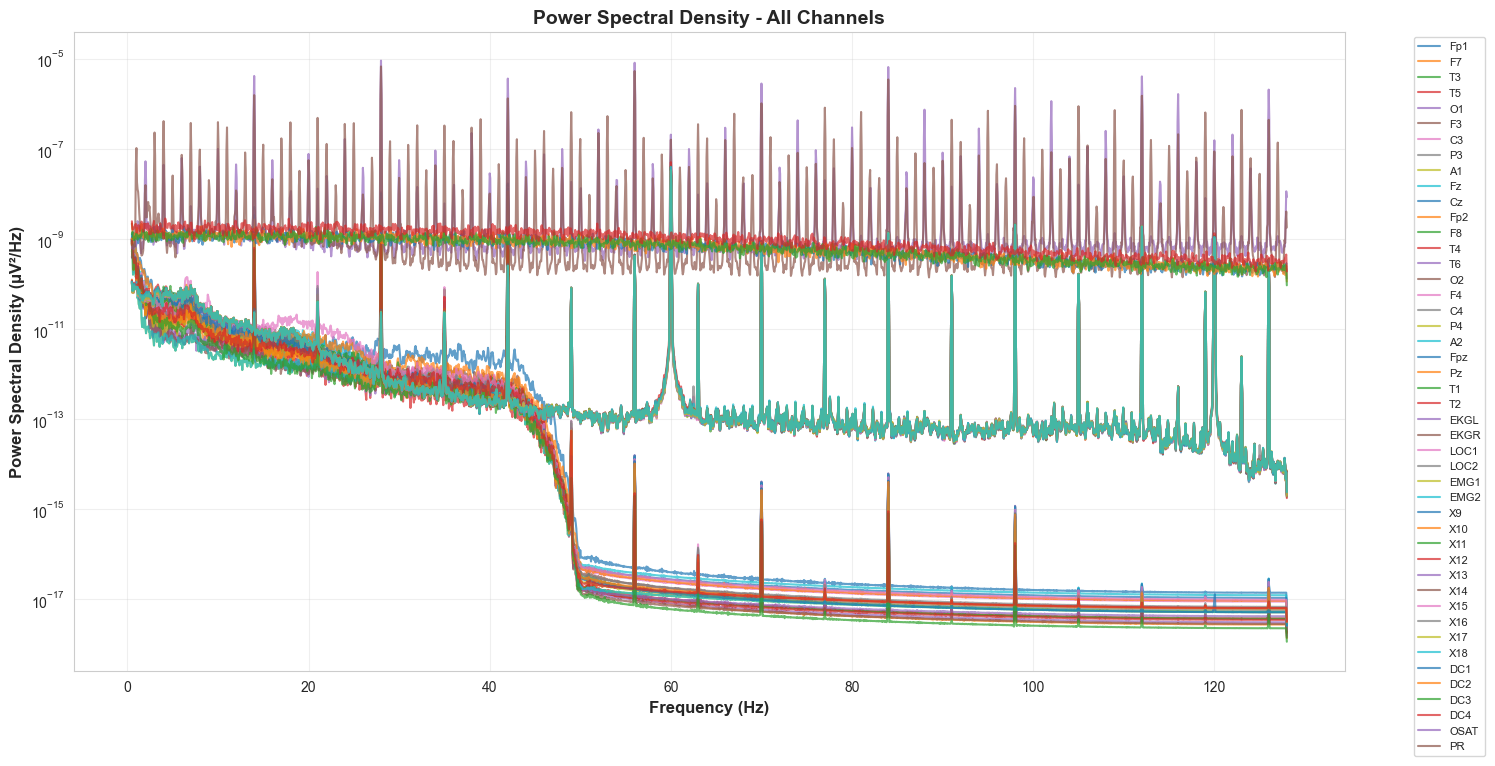

In [55]:
fig, ax = plt.subplots(figsize=(15, 8))

# Plot PSD for each channel
for idx, ch_name in enumerate(raw_filtered.ch_names):
    ax.semilogy(freqs_filt, psd_filt[idx, :], alpha=0.7, linewidth=1.5, label=ch_name)

ax.set_xlabel('Frequency (Hz)', fontsize=12, fontweight='bold')
ax.set_ylabel('Power Spectral Density (µV²/Hz)', fontsize=12, fontweight='bold')
ax.set_title('Power Spectral Density - All Channels', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()#

In [56]:
psd_mean = np.mean(psd_filt, axis=0)
psd_std = np.std(psd_filt, axis=0)

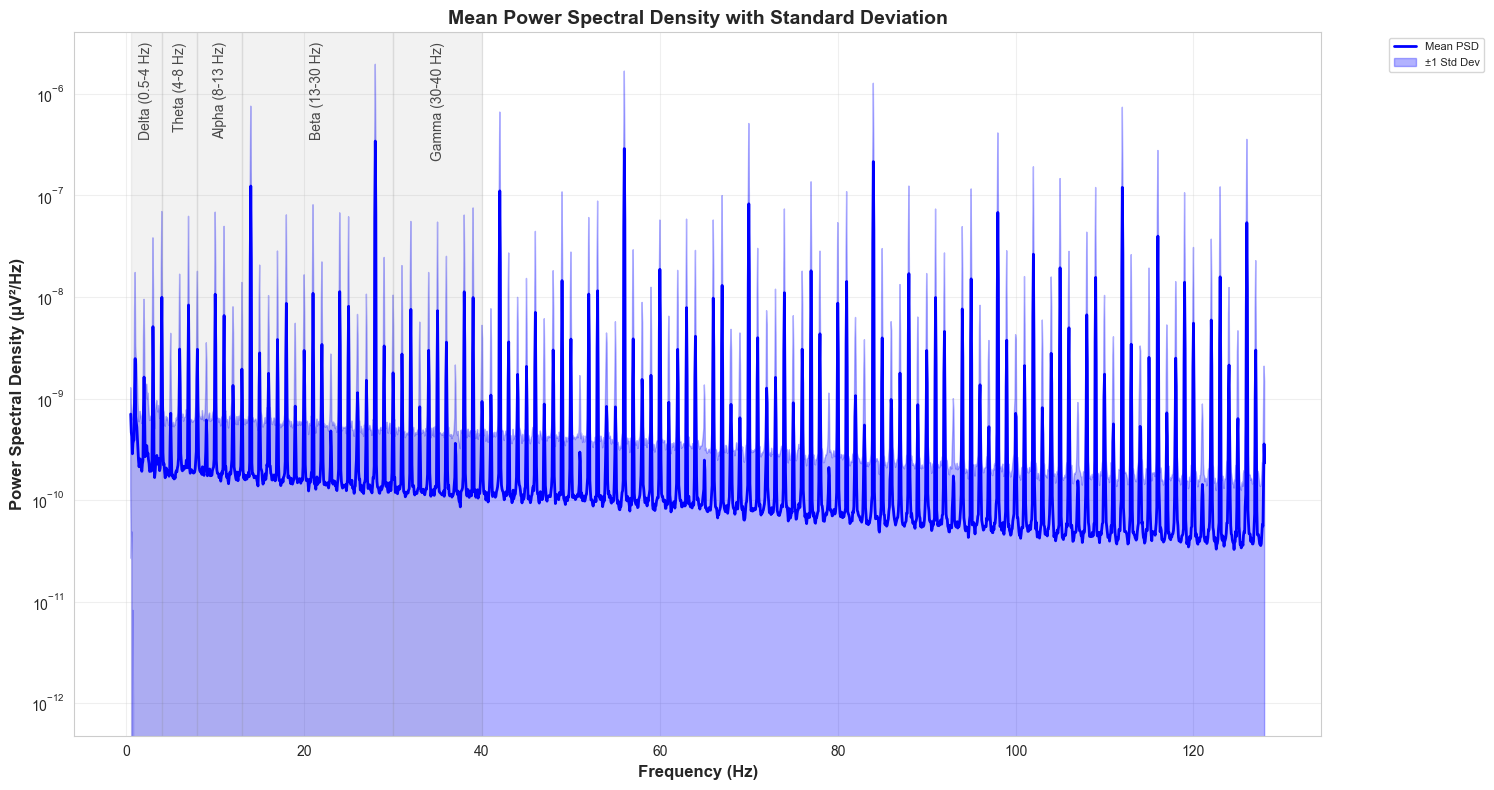

In [57]:
fig, ax = plt.subplots(figsize=(15, 8))

# Plot mean PSD with standard deviation
ax.semilogy(freqs_filt, psd_mean, color='blue', linewidth=2, label='Mean PSD')
ax.fill_between(freqs_filt, psd_mean - psd_std, psd_mean + psd_std, color='blue', alpha=0.3, label='±1 Std Dev')
ax.set_xlabel('Frequency (Hz)', fontsize=12, fontweight='bold')
ax.set_ylabel('Power Spectral Density (µV²/Hz)', fontsize=12, fontweight='bold')
ax.set_title('Mean Power Spectral Density with Standard Deviation', fontsize=14, fontweight='bold')

# Highlight frequency bands
for band, (fmin, fmax) in bands.items():
    ax.axvspan(fmin, fmax, color='gray', alpha=0.1)
    ax.text((fmin + fmax) / 2, ax.get_ylim()[1]*0.8, band, color='black', fontsize=10,
            ha='center', va='top', rotation=90, alpha=0.7)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [58]:
# Compute Band Power for Each Channel
band_powers = {}
for band, (fmin, fmax) in bands.items():
    band_powers[band] = np.trapz(psd_filt[:, (freqs_filt >= fmin) & (freqs_filt <= fmax)], axis=1)
band_power_df = pd.DataFrame(band_powers, index=raw_filtered.ch_names)
band_power_df.index.name = 'Channel'
print("\nBand Power (µV²) for Each Channel:")
print(band_power_df)


Band Power (µV²) for Each Channel:
         Delta (0.5-4 Hz)  Theta (4-8 Hz)  Alpha (8-13 Hz)  Beta (13-30 Hz)  \
Channel                                                                       
Fp1          1.536089e-08    2.468632e-09     1.080091e-09     1.397535e-08   
F7           6.233483e-09    9.731606e-10     4.655620e-10     1.297574e-08   
T3           6.487657e-09    3.487467e-09     1.191902e-09     1.231167e-08   
T5           4.432483e-09    1.173652e-09     4.846177e-10     6.545821e-09   
O1           4.332730e-09    4.634204e-10     3.644870e-10     6.191378e-09   
F3           6.614516e-09    1.341089e-09     7.563942e-10     2.068231e-08   
C3           6.485822e-09    2.598434e-09     1.508916e-09     2.245387e-08   
P3           5.277490e-09    1.662749e-09     8.215953e-10     1.495762e-08   
A1           2.957724e-09    3.554702e-10     2.105583e-10     3.580176e-10   
Fz           8.491680e-09    2.675912e-09     1.131764e-09     2.087327e-08   
Cz           6.3

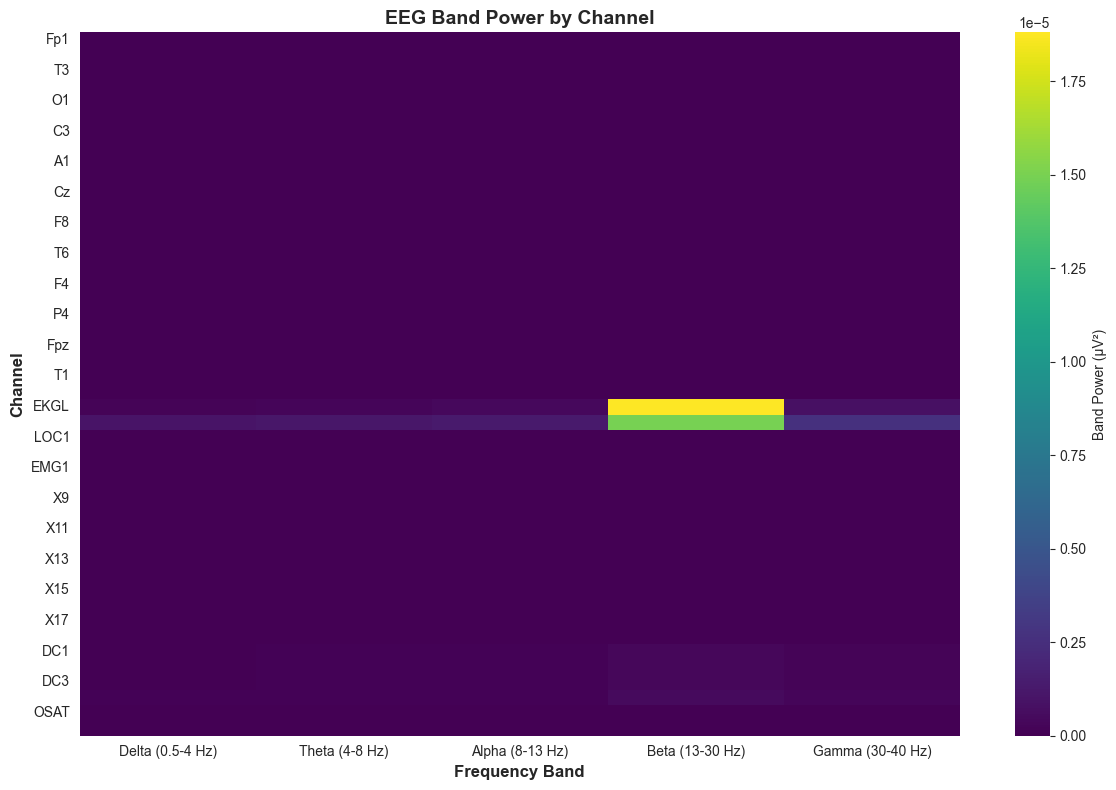

In [59]:
# Visualize Band Powers as Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(band_power_df, cmap='viridis', ax=ax, cbar_kws={'label': 'Band Power (µV²)'})
ax.set_title('EEG Band Power by Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency Band', fontsize=12, fontweight='bold')
ax.set_ylabel('Channel', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Available channels with positions: ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Fpz', 'Pz']
Total: 20 channels


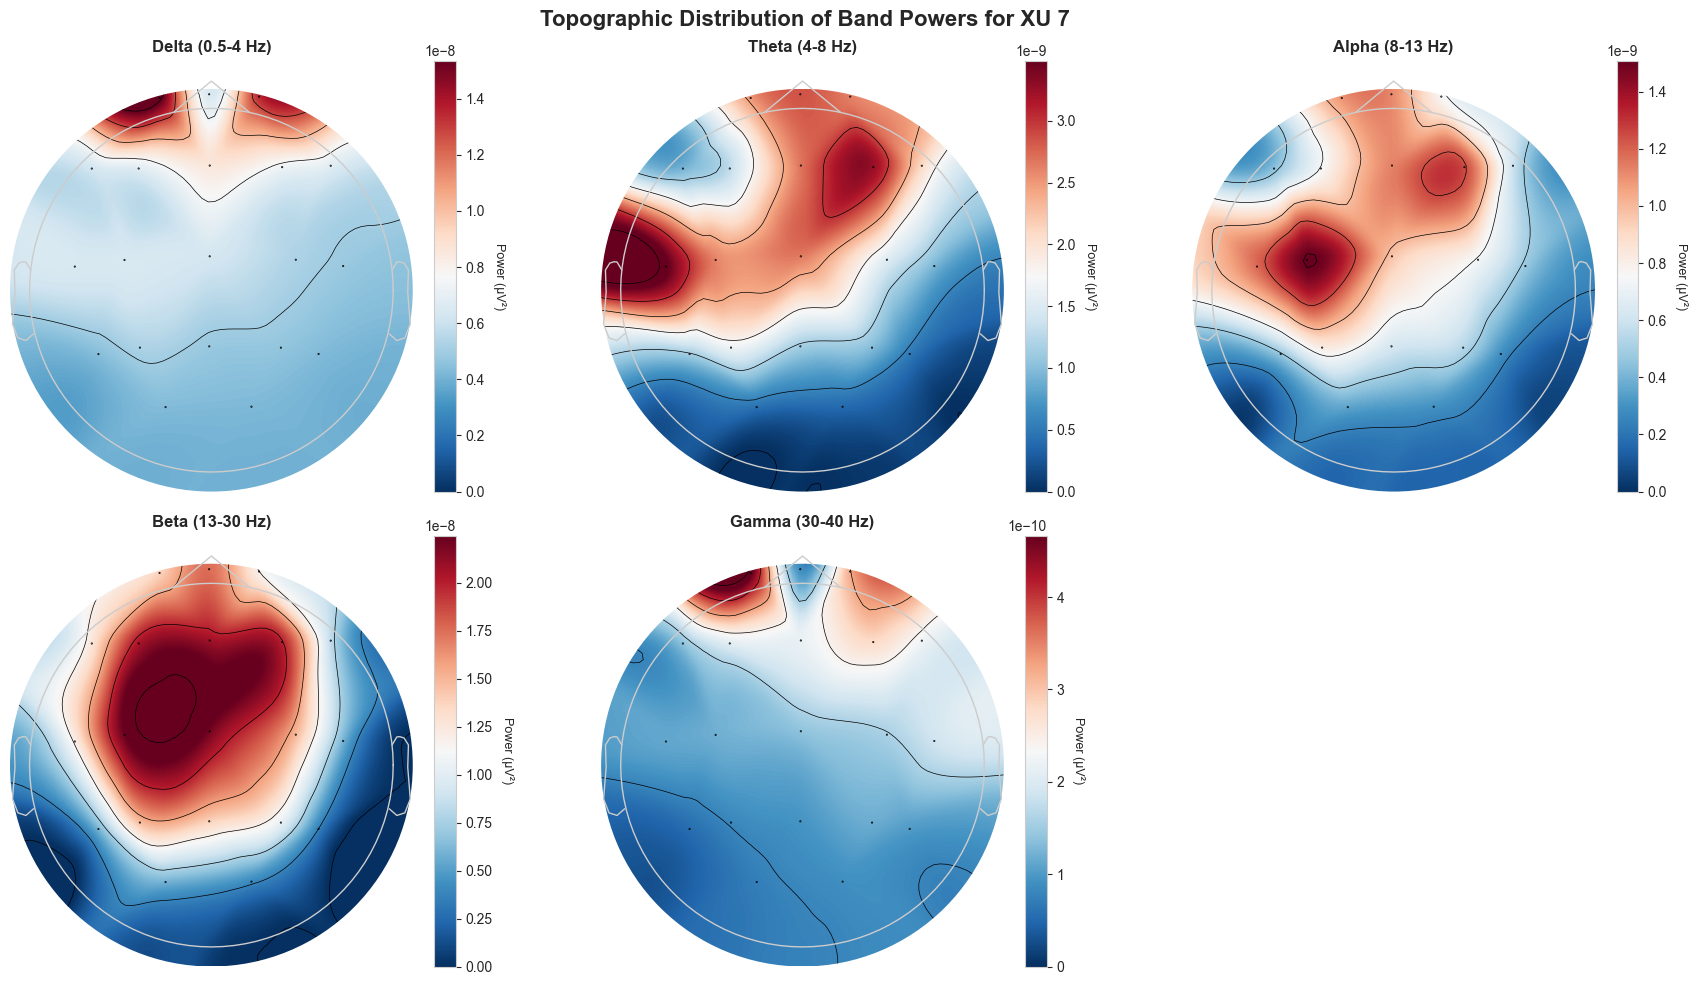


Successfully created topographic plots for 20 EEG channels


In [60]:
# Cell 12: Topographic Plot of Band Powers (if montage available)
try:
    # Get the standard montage
    montage = mne.channels.make_standard_montage('standard_1020')
    
    # Define standard 10-20 channels (excluding reference electrodes A1, A2)
    standard_eeg = ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 
                    'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Fpz', 'Pz']
    
    # Find which channels in your data exist in the standard montage
    available_channels = [ch for ch in raw_filtered.ch_names 
                         if ch in standard_eeg and ch in montage.ch_names]
    
    print(f"Available channels with positions: {available_channels}")
    print(f"Total: {len(available_channels)} channels")
    
    if len(available_channels) == 0:
        raise ValueError("No channels with standard positions found!")
    
    # Pick only these channels using the modern method
    raw_temp = raw_filtered.copy().pick(available_channels)
    raw_temp.set_montage(montage, on_missing='ignore')
    
    # Get indices of available channels in the original data
    ch_indices = [raw_filtered.ch_names.index(ch) for ch in available_channels]
    
    # Extract band powers for available channels
    eeg_band_powers = {}
    for band_name, powers in band_powers.items():
        eeg_band_powers[band_name] = powers[ch_indices]
    
    # Create a figure with subplots for each band
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, (band_name, powers) in enumerate(eeg_band_powers.items()):
        # Plot topography - removed invalid parameters
        im, cn = mne.viz.plot_topomap(
            powers, 
            raw_temp.info, 
            axes=axes[idx], 
            show=False,
            cmap='RdBu_r', 
            contours=6
        )
        axes[idx].set_title(band_name, fontsize=12, fontweight='bold')
        
        # Add colorbar for each subplot
        cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
        cbar.set_label('Power (µV²)', rotation=270, labelpad=15, fontsize=9)
    
    # Remove extra subplot
    fig.delaxes(axes[-1])

    plt.suptitle(f'Topographic Distribution of Band Powers for {patient} {freq}', 
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f'../figures/band_powers_topoview_{patient}_{freq}.png', dpi=300)
    plt.show()
    
    print(f"\nSuccessfully created topographic plots for {len(available_channels)} EEG channels")
    
except Exception as e:
    print(f"Could not create topographic plots: {e}")
    print("\nTroubleshooting:")
    print(f"1. Your channels: {raw_filtered.ch_names}")
    print(f"2. MNE version: {mne.__version__}")
    
    # Try alternative visualization
    print("\nCreating alternative bar plots instead...")
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, (band_name, powers) in enumerate(band_powers.items()):
        axes[idx].bar(range(len(powers)), powers)
        axes[idx].set_title(band_name, fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Channel Index')
        axes[idx].set_ylabel('Band Power (µV²)')
        axes[idx].grid(True, alpha=0.3)
    
    fig.delaxes(axes[-1])
    plt.suptitle('Band Powers by Channel (Bar Plot)', 
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

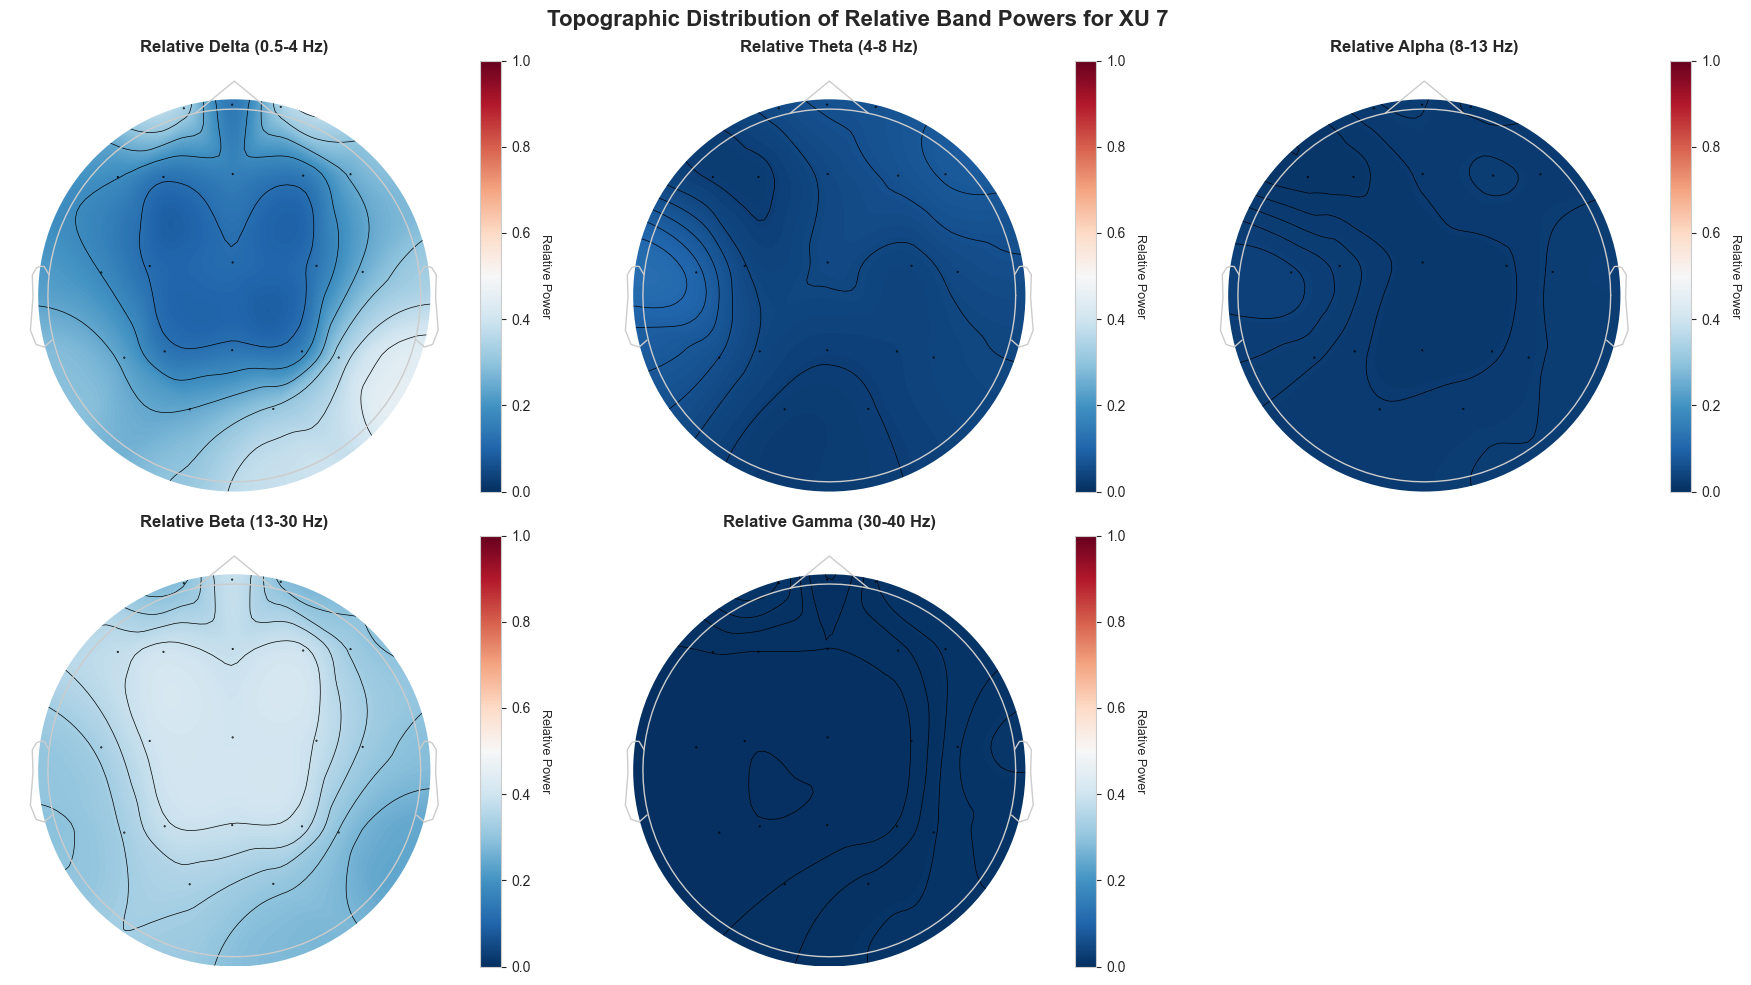


Successfully created topographic plots for 20 EEG channels


In [61]:
#plot Relative Power Topographic Maps 
try:
    # Calculate total power for each channel
    total_power = np.trapz(psd_filt, axis=1)
    
    # Calculate relative band powers
    relative_band_powers = {}
    for band, (fmin, fmax) in bands.items():
        band_power = np.trapz(psd_filt[:, (freqs_filt >= fmin) & (freqs_filt <= fmax)], axis=1)
        relative_band_powers[band] = band_power / total_power  # Relative power
    
    # Extract relative band powers for available channels
    eeg_relative_band_powers = {}
    for band_name, powers in relative_band_powers.items():
        eeg_relative_band_powers[band_name] = powers[ch_indices]
    
    # Create a figure with subplots for each band
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    vmin, vmax = 0, 1
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    for idx, (band_name, powers) in enumerate(eeg_relative_band_powers.items()):
        powers = np.clip(powers, 0, 1)
        im, cn = mne.viz.plot_topomap(
            powers,
            raw_temp.info,
            axes=axes[idx],
            show=False,
            cmap='RdBu_r',
            contours=6,
            sphere=0.10,
            vlim=(vmin, vmax)
        )
        axes[idx].set_title(f'Relative {band_name}', fontsize=12, fontweight='bold')
        cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, norm=norm)
        cbar.set_label('Relative Power', rotation=270, labelpad=15, fontsize=9)

    
    # Remove extra subplot
    fig.delaxes(axes[-1])

    plt.suptitle(f'Topographic Distribution of Relative Band Powers for {patient} {freq}', 
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f'../figures/relative_band_powers_topoview_{patient}_{freq}.png', dpi=300)
    plt.show()
    
    print(f"\nSuccessfully created topographic plots for {len(available_channels)} EEG channels")

except Exception as e:
    print(f"Could not create topographic plots: {e}")
    print("\nTroubleshooting:")
    print(f"1. Your channels: {raw_filtered.ch_names}")
    print(f"2. MNE version: {mne.__version__}")
    
    # Try alternative visualization
    print("\nCreating alternative bar plots instead...")
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, (band_name, powers) in enumerate(relative_band_powers.items()):
        axes[idx].bar(range(len(powers)), powers)
        axes[idx].set_title(f'Relative {band_name}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Channel Index')
        axes[idx].set_ylabel('Relative Band Power')
        axes[idx].grid(True, alpha=0.3)
    
    fig.delaxes(axes[-1])
    plt.suptitle('Relative Band Powers by Channel (Bar Plot)', 
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

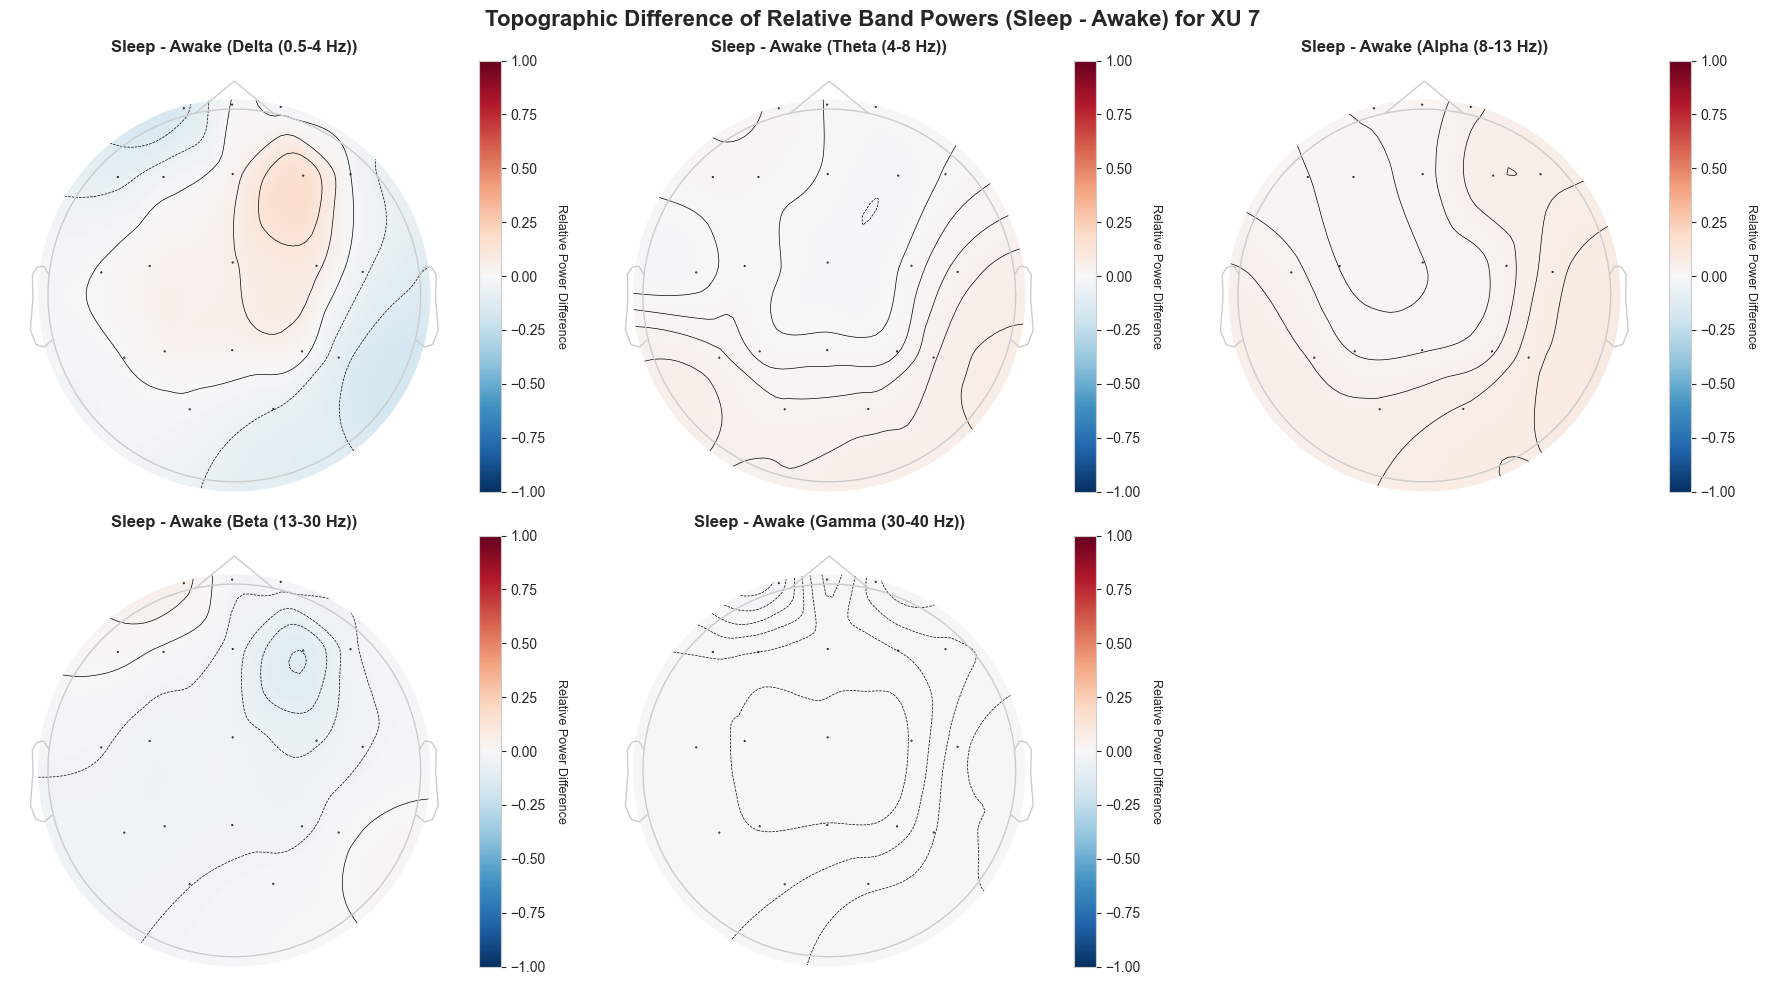


Successfully created difference topographic plots for 20 EEG channels


In [62]:
# Plot Relative Power Difference Topographic Maps (Sleep - Awake)
try:
    # Calculate total power for each channel
    total_power_sleep = np.trapz(psd_sleep_filt, axis=1)
    total_power_awake = np.trapz(psd_awake_filt, axis=1)
    
    # Calculate relative band powers
    relative_band_powers_sleep = {}
    relative_band_powers_awake = {}
    for band, (fmin, fmax) in bands.items():
        band_power_sleep = np.trapz(psd_sleep_filt[:, (freqs_filt >= fmin) & (freqs_filt <= fmax)], axis=1)
        band_power_awake = np.trapz(psd_awake_filt[:, (freqs_filt >= fmin) & (freqs_filt <= fmax)], axis=1)
        relative_band_powers_sleep[band] = band_power_sleep / total_power_sleep
        relative_band_powers_awake[band] = band_power_awake / total_power_awake
    
    # Compute difference (Sleep - Awake) for available channels
    eeg_relative_diff = {}
    for band_name in bands.keys():
        powers_sleep = relative_band_powers_sleep[band_name][ch_indices]
        powers_awake = relative_band_powers_awake[band_name][ch_indices]
        eeg_relative_diff[band_name] = powers_sleep - powers_awake  # difference

    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    vmin, vmax = -1, 1  # differences can be negative or positive
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    for idx, (band_name, diff_powers) in enumerate(eeg_relative_diff.items()):
        diff_powers = np.clip(diff_powers, vmin, vmax)
        im, cn = mne.viz.plot_topomap(
            diff_powers,
            raw_temp.info,
            axes=axes[idx],
            show=False,
            cmap='RdBu_r',
            contours=6,
            sphere=0.10,
            vlim=(vmin, vmax)
        )
        axes[idx].set_title(f'Sleep - Awake ({band_name})', fontsize=12, fontweight='bold')
        cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, norm=norm)
        cbar.set_label('Relative Power Difference', rotation=270, labelpad=15, fontsize=9)

    # Remove extra subplot if exists
    fig.delaxes(axes[-1])

    plt.suptitle(f'Topographic Difference of Relative Band Powers (Sleep - Awake) for {patient} {freq}', 
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f'../figures/diff_relative_band_powers_topoview_{patient}_{freq}.png', dpi=300)
    plt.show()
    
    print(f"\nSuccessfully created difference topographic plots for {len(available_channels)} EEG channels")

except Exception as e:
    print(f"Could not create topographic difference plots: {e}")
